In [1]:
from czitools.metadata_tools import CziMetadata
from czitools.metadata_tools.hcs import (
    resolve_field,
    resolve_well,
    well_relative_field_positions,
    well_absolute_field_positions
)
from czitools.read_tools import read_field, read_well
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define Parameters and variables
czifilepath = r"F:\Testdata_Zeiss\OME_ZARR_Testfiles\WP96_4Pos_B4-10_DAPI.czi"
metadata =  CziMetadata(czifilepath)
sample = metadata.sample
plate = metadata.hcs
selected_well = "B4"
tolerance = 1.0

In [3]:
print(f"File: {czifilepath}")
print(f"HCS detected: {metadata.hcs_status.detected}")
print(f"HCS Reason: {metadata.hcs_status.reason}")
print(f"Scene count: {sample.scene_count}")
print(f"Unique well count: {sample.well_unique_number}")
print(f"Multiple fields per well: {sample.multipos_per_well}")
print(f"Deprecated well_total_number: {sample.well_total_number} (scene count)")

File: F:\Testdata_Zeiss\OME_ZARR_Testfiles\WP96_4Pos_B4-10_DAPI.czi
HCS detected: True
HCS Reason: Complete and consistent CZI well metadata was found.
Scene count: 28
Unique well count: 7
Multiple fields per well: True
Deprecated well_total_number: 28 (scene count)


In [4]:
per_scene_lengths = {
        "well names": len(sample.well_array_names),
        "well indices": len(sample.well_indices),
        "position names": len(sample.well_position_names),
        "row indices": len(sample.well_rowID),
        "column indices": len(sample.well_colID),
        "field center X": len(sample.field_centerX),
        "field center Y": len(sample.field_centerY),
        "region IDs": len(sample.well_region_ids),
    }

print("\nPer-scene collection lengths:")
for label, length in per_scene_lengths.items():
    print(f"  {label:18}: {length}")

if sample.scene_count:
    print("\nFirst scene:")
    print(f"  well: {sample.well_array_names[0] or '<missing>'}")
    print(f"  RegionId: {sample.well_region_ids[0]}")
    print(
        "  scene center (preserves missing values): "
        f"({sample.field_centerX[0]}, {sample.field_centerY[0]}) micrometers"
   )


Per-scene collection lengths:
  well names        : 28
  well indices      : 28
  position names    : 28
  row indices       : 28
  column indices    : 28
  field center X    : 28
  field center Y    : 28
  region IDs        : 28

First scene:
  well: B4
  RegionId: 637232309317131710
  scene center (preserves missing values): (29687.5, 15687.5) micrometers


In [5]:
print("\nPlate:")
print(f"  ID: {plate.id}")
print(f"  name: {plate.name}")
print(f"  model schema: {plate.schema_version}")
print(f"  declared dimensions: {plate.declared_rows} rows x {plate.declared_columns} columns")
print(f"  observed 0-based rows: {plate.observed_row_indices}")
print(f"  observed 0-based columns: {plate.observed_column_indices}")
print(f"  wells present in this CZI: {len(plate.wells)}")
print(f"  fields present in this CZI: {sum(len(well.fields) for well in plate.wells)}")

print("\nWells:")
for well in plate.wells:
    print(
        f"  {well.canonical_name:>3}  path={well.canonical_path:<4} "
        f"CZI=({well.source_row_index}, {well.source_column_index}) "
        f"normalized=({well.row_index}, {well.column_index}) "
        f"fields={len(well.fields)}"
    )


Plate:
  ID: plate:WP96_4Pos_B4-10_DAPI.czi
  name: Multichamber 96
  model schema: 1.0
  declared dimensions: 8 rows x 12 columns
  observed 0-based rows: (1,)
  observed 0-based columns: (3, 4, 5, 6, 7, 8, 9)
  wells present in this CZI: 7
  fields present in this CZI: 28

Wells:
   B4  path=B/4  CZI=(2, 4) normalized=(1, 3) fields=4
   B5  path=B/5  CZI=(2, 5) normalized=(1, 4) fields=4
   B6  path=B/6  CZI=(2, 6) normalized=(1, 5) fields=4
   B7  path=B/7  CZI=(2, 7) normalized=(1, 6) fields=4
   B8  path=B/8  CZI=(2, 8) normalized=(1, 7) fields=4
   B9  path=B/9  CZI=(2, 9) normalized=(1, 8) fields=4
  B10  path=B/10 CZI=(2, 10) normalized=(1, 9) fields=4


In [6]:
# get_well normalizes capitalization and zero padding, so B04 resolves to B4.
well = plate.get_well(selected_well)
print(f"\nFields in requested well {selected_well!r} -> {well.canonical_name}:")
for field in well.fields:
    print(
        f"  local={field.field_index} scene={field.scene_index} id={field.id} "
        f"region={field.region_id} center=({field.scene_center_x}, {field.scene_center_y}) "
        f"{field.position_unit}"
        )


Fields in requested well 'B4' -> B4:
  local=0 scene=0 id=field:637232309317131710 region=637232309317131710 center=(29687.5, 15687.5) micrometer
  local=1 scene=1 id=field:637232309317131711 region=637232309317131711 center=(33312.5, 15687.5) micrometer
  local=2 scene=2 id=field:637232309317131708 region=637232309317131708 center=(29687.5, 19312.5) micrometer
  local=3 scene=3 id=field:637232309317131709 region=637232309317131709 center=(33312.5, 19312.5) micrometer


In [7]:
# Pure resolution (no pixel reading). resolve_well normalizes the name.
well = resolve_well(plate, selected_well)
print(f"Resolved well {selected_well!r} -> {well.canonical_name} with {len(well.fields)} field(s).")
first_field = resolve_field(plate, selected_well, 0)
print(f"field 0 -> scene={first_field.scene_index} id={first_field.id} region={first_field.region_id}")

Resolved well 'B4' -> B4 with 4 field(s).
field 0 -> scene=0 id=field:637232309317131710 region=637232309317131710



read_field('B4', 0):
2026-07-22 17:15:48,042 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


shape=(1, 1, 1, 1, 640, 640) dims=('S', 'T', 'C', 'Z', 'Y', 'X')


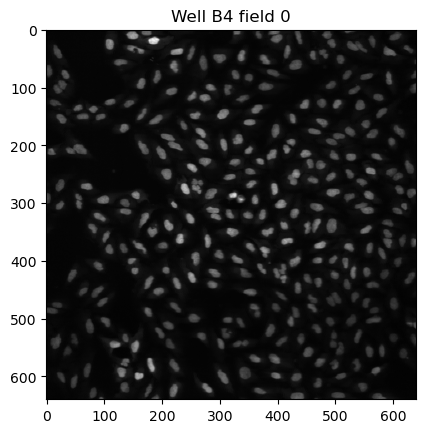

In [8]:
# Read a single field (field 0) -> one scene, returned as an xarray.DataArray.
print(f"\nread_field({well.canonical_name!r}, 0):")
array, _ = read_field(czifilepath, selected_well, 0, use_xarray=True)
if array is not None:
    print(f"shape={array.shape} dims={getattr(array, 'dims', None)}")

    plt.figure()
    plt.imshow(array[0, 0, 0, 0, ...], cmap="gray")
    plt.title(f"Well {well.canonical_name} field 0")
    plt.show()



read_field('B4', region_id='637232309317131710'):
2026-07-22 17:15:48,536 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


shape=(1, 1, 1, 1, 640, 640)


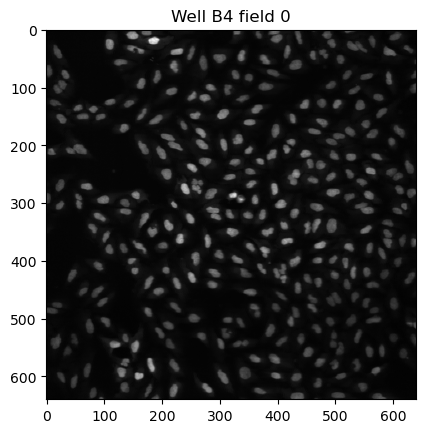

In [9]:
# Read a single field by its RegionId (equivalent to the local index above).
if first_field.region_id is not None:
    print(f"\nread_field({well.canonical_name!r}, region_id={first_field.region_id!r}):")
    array_by_region, _ = read_field(czifilepath, selected_well, first_field.region_id)

    if array_by_region is not None:
        print(f"shape={array_by_region.shape}")
        plt.figure()
        plt.imshow(array_by_region[0, 0, 0, 0, ...], cmap="gray")
        plt.title(f"Well {well.canonical_name} field 0")
        plt.show()


read_well('B4') -> list of per-field arrays:
2026-07-22 17:15:48,834 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-22 17:15:48,925 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-22 17:15:49,115 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-22 17:15:49,203 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


Type of arrays: <class 'list'>, Length: 4
  field 0: shape=(1, 1, 1, 1, 640, 640)
  field 1: shape=(1, 1, 1, 1, 640, 640)
  field 2: shape=(1, 1, 1, 1, 640, 640)
  field 3: shape=(1, 1, 1, 1, 640, 640)


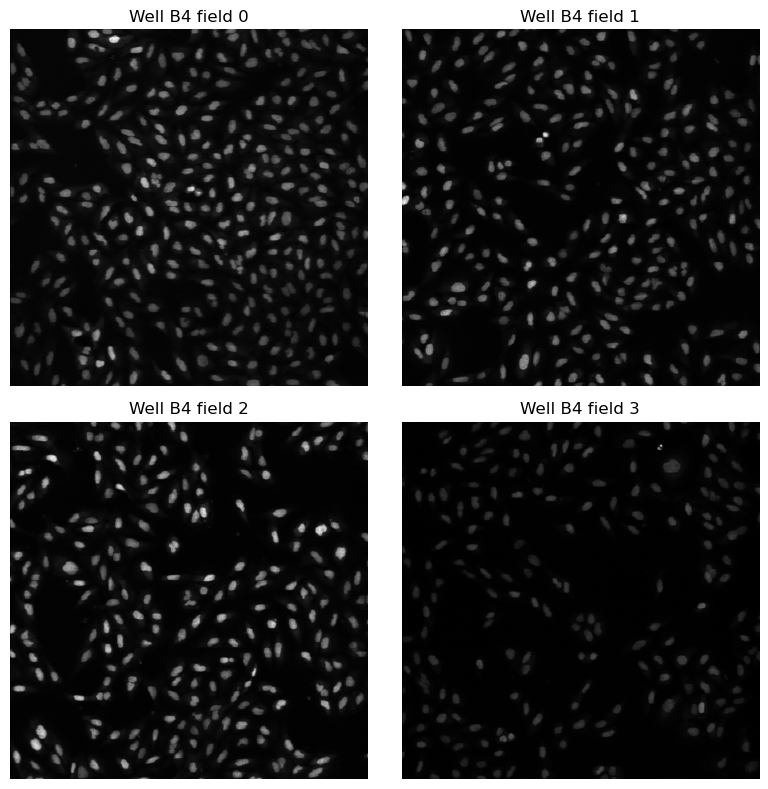

In [10]:
# Read all fields of the well as a list (fields may differ in shape).
print(f"\nread_well({well.canonical_name!r}) -> list of per-field arrays:")
arrays, _ = read_well(czifilepath, selected_well)
print(f"Type of arrays: {type(arrays)}, Length: {len(arrays) if arrays is not None else 'N/A'}")

if isinstance(arrays, list):
    for index, field_array in enumerate(arrays):
        print(f"  field {index}: shape={field_array.shape}")

if arrays and len(arrays) > 0:
    n_fields = len(arrays)
    n_cols = int(np.ceil(np.sqrt(n_fields)))
    n_rows = int(np.ceil(n_fields / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for idx, field_array in enumerate(arrays):
        axes[idx].imshow(field_array[0, 0, 0, 0, ...], cmap="gray")
        axes[idx].set_title(f"Well {well.canonical_name} field {idx}")
        axes[idx].axis("off")

    for idx in range(n_fields, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

In [11]:
# Stack the fields along S (only allowed when all field shapes match).
print(f"\nread_well({well.canonical_name!r}, stack=True) -> single stacked array:")
try:
    stacked, _ = read_well(czifilepath, selected_well, stack=True)
    if stacked is not None:
        print(f"  stacked shape={stacked.shape} (S = number of fields)")
except ValueError as error:
    print(f"  cannot stack: {error}")

print(f"Type of stacked: {type(stacked)}, Shape: {stacked.shape if stacked is not None else 'N/A'}")


read_well('B4', stack=True) -> single stacked array:
2026-07-22 17:15:49,693 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-22 17:15:49,783 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-22 17:15:49,895 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-22 17:15:50,004 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


  stacked shape=(4, 1, 1, 1, 640, 640) (S = number of fields)
Type of stacked: <class 'xarray.core.dataarray.DataArray'>, Shape: (4, 1, 1, 1, 640, 640)


In [12]:
# Before enrichment: only the scene-center (Scene.CenterPosition) is known.
well_before = metadata.hcs.get_well(selected_well)
print(f"\nBefore enrichment, well {well_before.canonical_name}:")
for field in well_before.fields:
    print(
        f"  local={field.field_index} scene={field.scene_index} "
        f"scene_center=({field.scene_center_x}, {field.scene_center_y}) {field.position_unit} "
        f"stage_x={field.stage_x}"
    )


Before enrichment, well B4:
  local=0 scene=0 scene_center=(29687.5, 15687.5) micrometer stage_x=None
  local=1 scene=1 scene_center=(33312.5, 15687.5) micrometer stage_x=None
  local=2 scene=2 scene_center=(29687.5, 19312.5) micrometer stage_x=None
  local=3 scene=3 scene_center=(33312.5, 19312.5) micrometer stage_x=None


In [13]:
# Opt-in enrichment. This scans subblocks and replaces metadata.hcs with an
# enriched copy. The original plate object is not mutated.
print(f"\nEnriching from the planetable (position_tolerance={tolerance} um)...")
enriched = metadata.enrich_hcs_positions(position_tolerance=tolerance)

if enriched is None:
    print("Enrichment returned no plate (e.g. URL source or no subblock positions).")

well = enriched.get_well(selected_well)
print(f"\nAfter enrichment, well {well.canonical_name}:")
for field in well.fields:
    print(
        f"  local={field.field_index} scene={field.scene_index} "
        f"subblocks={field.subblock_count} conflict={field.position_conflict}"
    )
    print(
        f"      stage_x={field.stage_x} range={field.stage_x_range}  "
        f"stage_y={field.stage_y} range={field.stage_y_range}"
    )
    print(
        f"      focus_z={field.acquisition_z} range={field.acquisition_z_range} "
        f"({field.stage_unit}, source={field.stage_source})"
        )

  0% |                                                  | ETA:  --:--:-- 0 of 28
100% |#################################################| Time:  0:00:00 28 of 28



Enriching from the planetable (position_tolerance=1.0 um)...

After enrichment, well B4:
  local=0 scene=0 subblocks=1 conflict=False
      stage_x=29687.5 range=(29687.5, 29687.5)  stage_y=15687.5 range=(15687.5, 15687.5)
      focus_z=111.842 range=(111.842, 111.842) (micrometer, source=planetable(StageXPosition,StageYPosition,FocusPosition))
  local=1 scene=1 subblocks=1 conflict=False
      stage_x=33312.5 range=(33312.5, 33312.5)  stage_y=15687.5 range=(15687.5, 15687.5)
      focus_z=111.842 range=(111.842, 111.842) (micrometer, source=planetable(StageXPosition,StageYPosition,FocusPosition))
  local=2 scene=2 subblocks=1 conflict=False
      stage_x=29687.5 range=(29687.5, 29687.5)  stage_y=19312.5 range=(19312.5, 19312.5)
      focus_z=111.842 range=(111.842, 111.842) (micrometer, source=planetable(StageXPosition,StageYPosition,FocusPosition))
  local=3 scene=3 subblocks=1 conflict=False
      stage_x=33312.5 range=(33312.5, 33312.5)  stage_y=19312.5 range=(19312.5, 19312.5)
  


Well-relative field offsets (um from field centroid) for B4:
  local=0: dx=-1812.500, dy=-1812.500
  local=1: dx=1812.500, dy=-1812.500
  local=2: dx=-1812.500, dy=1812.500
  local=3: dx=1812.500, dy=1812.500


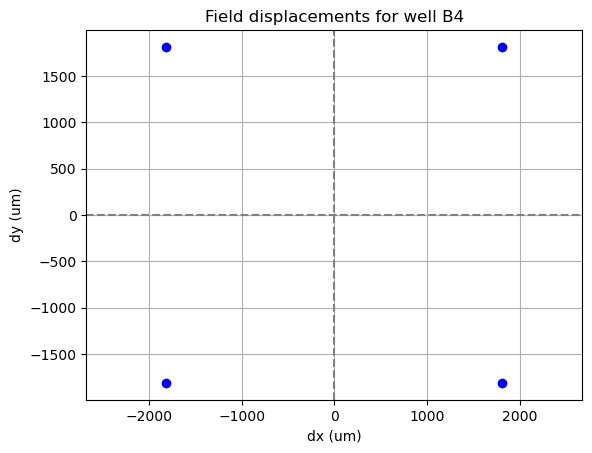

In [14]:
# Well-relative offsets use the centroid of the well's field scene-centers as
# origin, or return None when any scene-center is missing.
offsets = well_relative_field_positions(well)
print(f"\nWell-relative field offsets (um from field centroid) for {well.canonical_name}:")
if offsets is None:
    print("  unavailable (a field is missing its scene-center position)")
else:
    for field_index, (dx, dy) in offsets.items():
        print(f"  local={field_index}: dx={dx:.3f}, dy={dy:.3f}")

# plot the field displacements as dots around the center postion
if offsets is not None:
    dxs, dys = zip(*offsets.values())
    plt.figure()
    plt.scatter(dxs, dys, marker="o", color="blue")
    plt.axhline(0, color="gray", linestyle="--")
    plt.axvline(0, color="gray", linestyle="--")
    plt.title(f"Field displacements for well {well.canonical_name}")
    plt.xlabel("dx (um)")
    plt.ylabel("dy (um)")
    plt.axis("equal")
    plt.grid()
    plt.show()


Absolute field positions (um, source='scene_center') for B4:
  local=0: x=29687.500, y=15687.500
  local=1: x=33312.500, y=15687.500
  local=2: x=29687.500, y=19312.500
  local=3: x=33312.500, y=19312.500


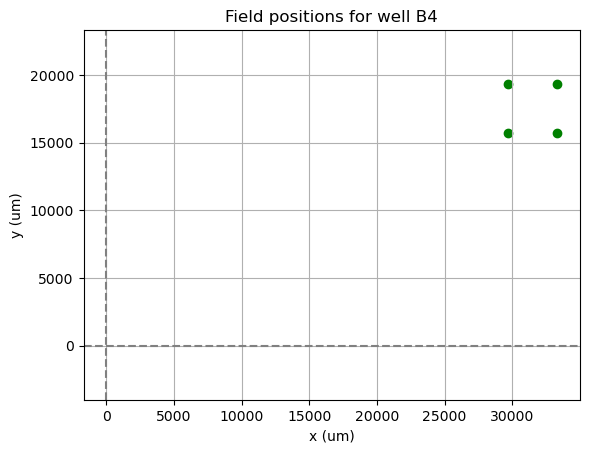

In [15]:
scene_positions = well_absolute_field_positions(well, source="scene_center")
print(f"\nAbsolute field positions (um, source='scene_center') for {well.canonical_name}:")
if scene_positions is None:
    print("  unavailable (a field is missing its scene-center position)")
else:
    for field_index, (x, y) in scene_positions.items():
        print(f"  local={field_index}: x={x:.3f}, y={y:.3f}")

# plot the field positions as dots around the center postion
if scene_positions is not None:
    xs, ys = zip(*scene_positions.values())
    plt.figure()
    plt.scatter(xs, ys, marker="o", color="green")
    plt.axhline(0, color="gray", linestyle="--")
    plt.axvline(0, color="gray", linestyle="--")
    plt.title(f"Field positions for well {well.canonical_name}")
    plt.xlabel("x (um)")
    plt.ylabel("y (um)")
    plt.axis("equal")
    plt.grid()
    plt.show()